# Utilization of hospital beds during epidemics

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, norm, chisquare, kstest, expon, uniform
from scipy import stats
import scipy


We assume (for convenience) that the intensity of the epudemuc behaves as a second-order polynomial startubnf ar $t=0$ and in $t=356$

# Primary task

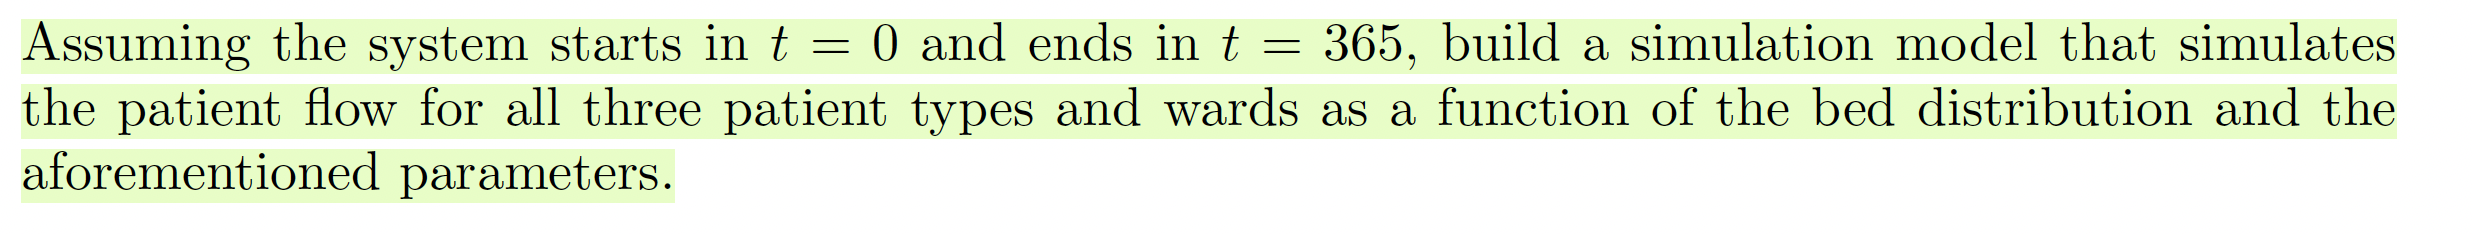

We have that for each day out of the 365 days we have it possion distributed. so we make 365 simulations, 


In [22]:
n = 10000
np.random.seed(42)


def patient_flow_one_day(t, l, patient_type):
    # we have an arrival rate for each ward
    patients = []
    #we generate arrivals per day so mean of ward c is that we wait 1/6  of a day between each patients.
    t_init = t
    while t < t_init + 1:
        wait =np.random.exponential(1/l)
        t += wait
        # Only record the patient if they arrived before the day ended
        if t < t_init + 1:
            patients.append([t, int(patient_type)])
        else:
            break 
    return patients


def patient_flow_year():
    patient_type = np.array([1,2,3])
    t= 1

    patients_year = []

    while t < 365:
        patients_a_day =[]

        lA = - (1/3650) * t**2 + (1/10)*t 
        lB = 1/5 * lA 
        lC = 6
        l = [lA, lB, lC]

        for i in range(len(patient_type)):
            patient_i_day_t =patient_flow_one_day(t, l[i], patient_type[i])
            patients_a_day.append(patient_i_day_t)
        t += 1
        patients_year.append(patients_a_day)

    return  patients_year

patients= patient_flow_year()

#the type 1 and 2 patients peak around the middle of the year so thats why it dosent show when printing patients.
# Find the exact days where a Type 2 patient actually showed up
for day_index, day_data in enumerate(patients):
    ward_2_patients = day_data[1]  # Index 1 is Ward B / Type 2
    if len(ward_2_patients) > 0:
        print(f"Day {day_index + 1}: Found Type 2 arrival! Details: {ward_2_patients}")

Day 15: Found Type 2 arrival! Details: [[15.130650803661101, 2]]
Day 16: Found Type 2 arrival! Details: [[16.88678911087544, 2]]
Day 17: Found Type 2 arrival! Details: [[17.79226515952552, 2]]
Day 18: Found Type 2 arrival! Details: [[18.871673791806302, 2]]
Day 28: Found Type 2 arrival! Details: [[28.91083047841012, 2]]
Day 29: Found Type 2 arrival! Details: [[29.167087569690644, 2], [29.266475706016912, 2]]
Day 33: Found Type 2 arrival! Details: [[33.296259114184316, 2], [33.41816304460385, 2]]
Day 34: Found Type 2 arrival! Details: [[34.791245545951746, 2]]
Day 36: Found Type 2 arrival! Details: [[36.81986222672113, 2]]
Day 37: Found Type 2 arrival! Details: [[37.163668813301136, 2]]
Day 40: Found Type 2 arrival! Details: [[40.65817583704456, 2]]
Day 41: Found Type 2 arrival! Details: [[41.758401425535666, 2]]
Day 42: Found Type 2 arrival! Details: [[42.01645129253657, 2]]
Day 43: Found Type 2 arrival! Details: [[43.97595708367428, 2]]
Day 44: Found Type 2 arrival! Details: [[44.7858

In [29]:
np.random.seed(42)
patients= patient_flow_year()
patients

[[[],
  [],
  [[1.2194576155909083, 3],
   [1.3716147078869005, 3],
   [1.399885519630625, 3],
   [1.4281515682830592, 3],
   [1.438124696384506, 3],
   [1.773329840464496, 3],
   [1.9265101994023732, 3]]],
 [[[2.1045695236871294, 1]],
  [],
  [[2.0397812708748244, 3],
   [2.0732277689997685, 3],
   [2.106996339471811, 3],
   [2.1674552943818908, 3],
   [2.291443266192033, 3],
   [2.3856994439887558, 3],
   [2.443069942747746, 3],
   [2.600798421731046, 3],
   [2.625837509852269, 3],
   [2.683423428519336, 3],
   [2.7594696315561436, 3],
   [2.8609587461994392, 3]]],
 [[[3.7486057981304968, 1]],
  [],
  [[3.007927308292735, 3],
   [3.16381614506767, 3],
   [3.194976353730573, 3],
   [3.2061870088771234, 3],
   [3.7018016411282786, 3]]],
 [[],
  [],
  [[4.017129552500418, 3],
   [4.209254679683528, 3],
   [4.3059364867810945, 3],
   [4.327628525773503, 3],
   [4.441553063795861, 3],
   [4.447385350703107, 3],
   [4.847455831935278, 3],
   [4.897365461408726, 3]]],
 [[[5.757469457250181,

In [ ]:
# Flatten the deeply nested structure and sort everything chronologically by time
flat_patients = sorted([p for block in patients for sublist in block for p in sublist], key=lambda x: x[0])
flat_patients

[[1.2194576155909083, 3],
 [1.3716147078869005, 3],
 [1.399885519630625, 3],
 [1.4281515682830592, 3],
 [1.438124696384506, 3],
 [1.773329840464496, 3],
 [1.9265101994023732, 3],
 [2.0397812708748244, 3],
 [2.0732277689997685, 3],
 [2.1045695236871294, 1],
 [2.106996339471811, 3],
 [2.1674552943818908, 3],
 [2.291443266192033, 3],
 [2.3856994439887558, 3],
 [2.443069942747746, 3],
 [2.600798421731046, 3],
 [2.625837509852269, 3],
 [2.683423428519336, 3],
 [2.7594696315561436, 3],
 [2.8609587461994392, 3],
 [3.007927308292735, 3],
 [3.16381614506767, 3],
 [3.194976353730573, 3],
 [3.2061870088771234, 3],
 [3.7018016411282786, 3],
 [3.7486057981304968, 1],
 [4.017129552500418, 3],
 [4.209254679683528, 3],
 [4.3059364867810945, 3],
 [4.327628525773503, 3],
 [4.441553063795861, 3],
 [4.447385350703107, 3],
 [4.847455831935278, 3],
 [4.897365461408726, 3],
 [5.034064766584651, 3],
 [5.616199288707355, 3],
 [5.757469457250181, 1],
 [5.8649068515637115, 3],
 [6.424905896544901, 3],
 [6.440348

In [34]:
75-30-10

35

In [38]:
# Now time to simulate the bed flow.

def ward_flow_year(init_dist, patient_flow):
    discarded_A= 0
    discarded_B= 0
    discarded_C= 0

    #same for all
    sigma2 = np.log(2)

    t = 0

    #List of 0 that has the length of beds, we input the times a person stay in the ward at the bed.
    ward_A = np.zeros(init_dist[0])
    ward_B = np.zeros(init_dist[1])
    ward_C = np.zeros(init_dist[2])

    for t, type in patient_flow:
        #release beds if time t has suprpassed the length of the patients stay
        ward_A[ward_A <= t] = 0
        ward_B[ward_B <= t] = 0
        ward_C[ward_C <= t] = 0

        #exstract the index for where the there is empty bedts
        empty_beds_A = np.where(ward_A == 0)[0]
        empty_beds_B = np.where(ward_B == 0)[0]
        empty_beds_C = np.where(ward_C == 0)[0]

        if type == 3:
            #LOS -> length of stay
            mu = np.log(5*np.sqrt(2))
            LOS = np.random.lognormal(mu, sigma2)
            if len(empty_beds_C) > 0:
                #takes the first bed in the empty bed list and fills it with the time that patients stays.
                bed = empty_beds_C[0]
                ward_C[bed] = t + LOS
            else: 
                discarded_C += 1

        if type == 2:
            mu = np.log(6*np.sqrt(2))
            LOS = np.random.lognormal(mu, sigma2)
            if len(empty_beds_B) > 0:
                bed = empty_beds_B[0]
                ward_B[bed] = t + LOS
             #If there is no space in B we sent to A
            elif len(empty_beds_A) > 0: 
                discarded_B += 1
                bed = empty_beds_A[0]
                ward_A[bed] = t + LOS
            else:
                # if A is occupied,
                #  we discard the patient closes to beign 
                # sent home, and then admit to A
                discarded_A += 1    
                bed = np.random.choice(len(ward_A))
                ward_A[bed] = t + LOS

        if type == 1:
            mu = np.log(4*np.sqrt(2))
            LOS = np.random.lognormal(mu, sigma2)
            if len(empty_beds_A) > 0:
                bed = empty_beds_A[0]
                ward_A[bed] = t + LOS
            else: 
                discarded_A += 1
    return discarded_A, discarded_B, discarded_C
# We start by having 75 beds in C. 
init_dist = [40, 0, 35 ]
ward_flow_year(init_dist, flat_patients)



(1217, 239, 818)

In [39]:
len(flat_patients)

4896

## Primary performance measures

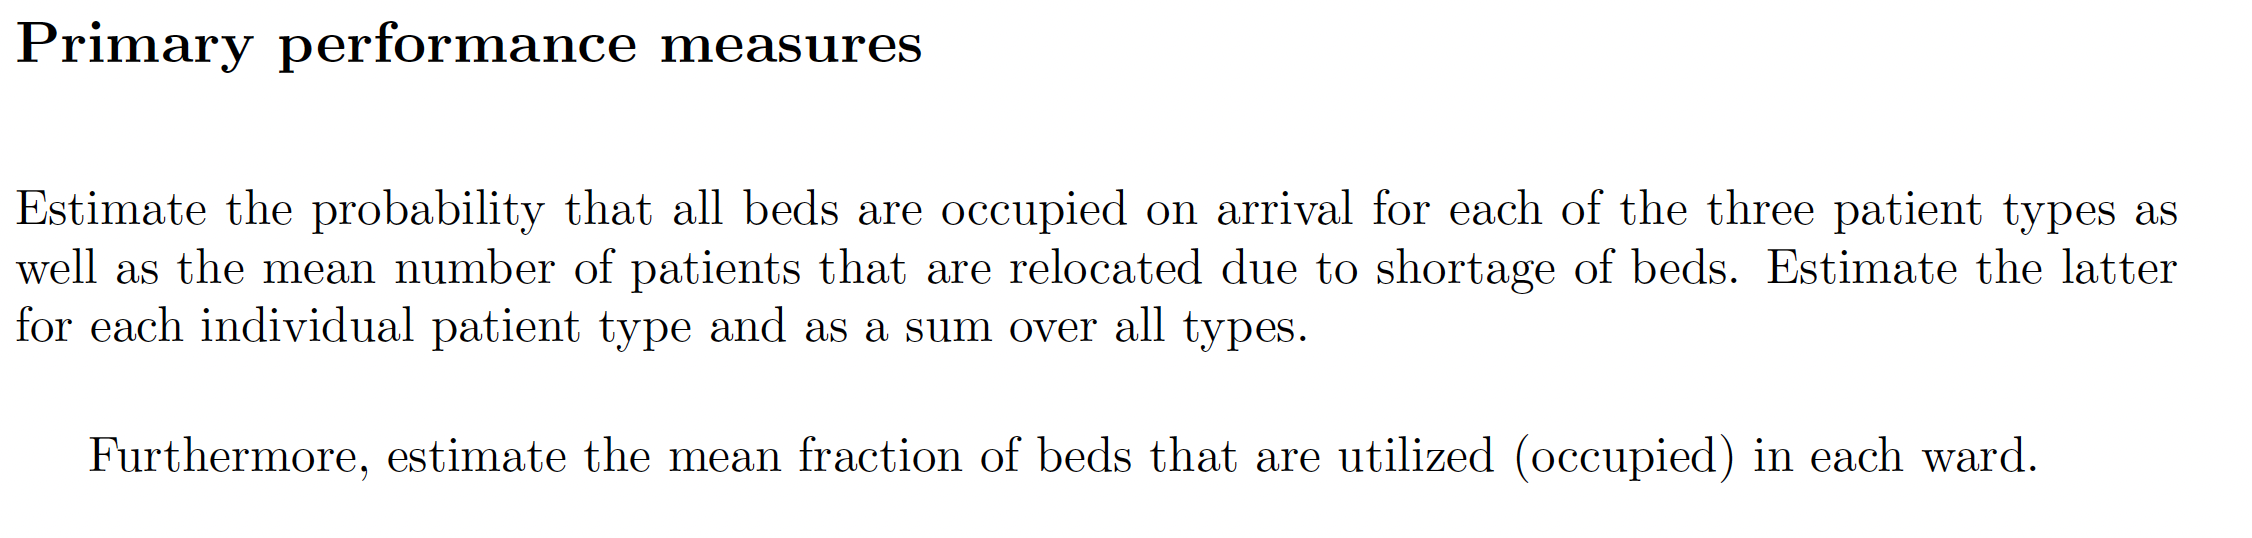